# ENVIRONMENT SETUP

In [2]:
import random

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from torchvision.transforms import functional as TF

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


device: cuda


# PARAMETER CONFIG
Zwięszyłem liczbę `epochs`, czyli ile razy model w pełni przeskanuje bazę obrazów.

In [3]:
# ZADANIE: Dobierz parametry tak, aby uzyskać satysfakcjonujące wyniki segmentacji.
CONFIG = {
    "data_root": "./data_voc",
    "image_size": 128,
    "batch_size": 8,
    "num_workers": 2,

    "num_classes": 21,
    "ignore_index": 255,

    "lr": 1e-3,
    "epochs": 10,           # Zwiększ liczbę epok
    "max_steps_per_epoch": None, # Ustaw None, aby trenować na pełnym zbiorze
}

print(CONFIG)

{'data_root': './data_voc', 'image_size': 128, 'batch_size': 8, 'num_workers': 2, 'num_classes': 21, 'ignore_index': 255, 'lr': 0.001, 'epochs': 10, 'max_steps_per_epoch': None}


In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class VOCResizeWrapper(Dataset):
    def __init__(self, voc_dataset, image_size):
        self.voc = voc_dataset
        self.image_size = image_size

    def __len__(self):
        return len(self.voc)

    def __getitem__(self, idx):
        img, mask = self.voc[idx]  # PIL image + PIL mask

        img = img.resize((self.image_size, self.image_size), resample=Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), resample=Image.NEAREST)

        img_t = TF.to_tensor(img)
        img_t = TF.normalize(img_t, IMAGENET_MEAN, IMAGENET_STD)

        mask_np = np.array(mask, dtype=np.uint8)
        mask_t = torch.from_numpy(mask_np).long()  # [H, W]
        return img_t, mask_t


train_base = datasets.VOCSegmentation(
    root=CONFIG["data_root"],
    year="2012",
    image_set="train",
    download=True,
)

val_base = datasets.VOCSegmentation(
    root=CONFIG["data_root"],
    year="2012",
    image_set="val",
    download=True,
)

train_ds = VOCResizeWrapper(train_base, CONFIG["image_size"])
val_ds = VOCResizeWrapper(val_base, CONFIG["image_size"])

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

img_t, mask_t = train_ds[0]
print("img_t:", img_t.shape, "mask_t:", mask_t.shape)
print("mask unique sample:", torch.unique(mask_t)[:10])


100%|██████████| 2.00G/2.00G [01:54<00:00, 17.5MB/s]


img_t: torch.Size([3, 128, 128]) mask_t: torch.Size([128, 128])
mask unique sample: tensor([  0,   1,  15, 255])


### Podgląd danych wejściowych (VOC)
Wyświetlamy kilka przykładowych obrazów ze zbioru treningowego wraz z ich maskami segmentacji.

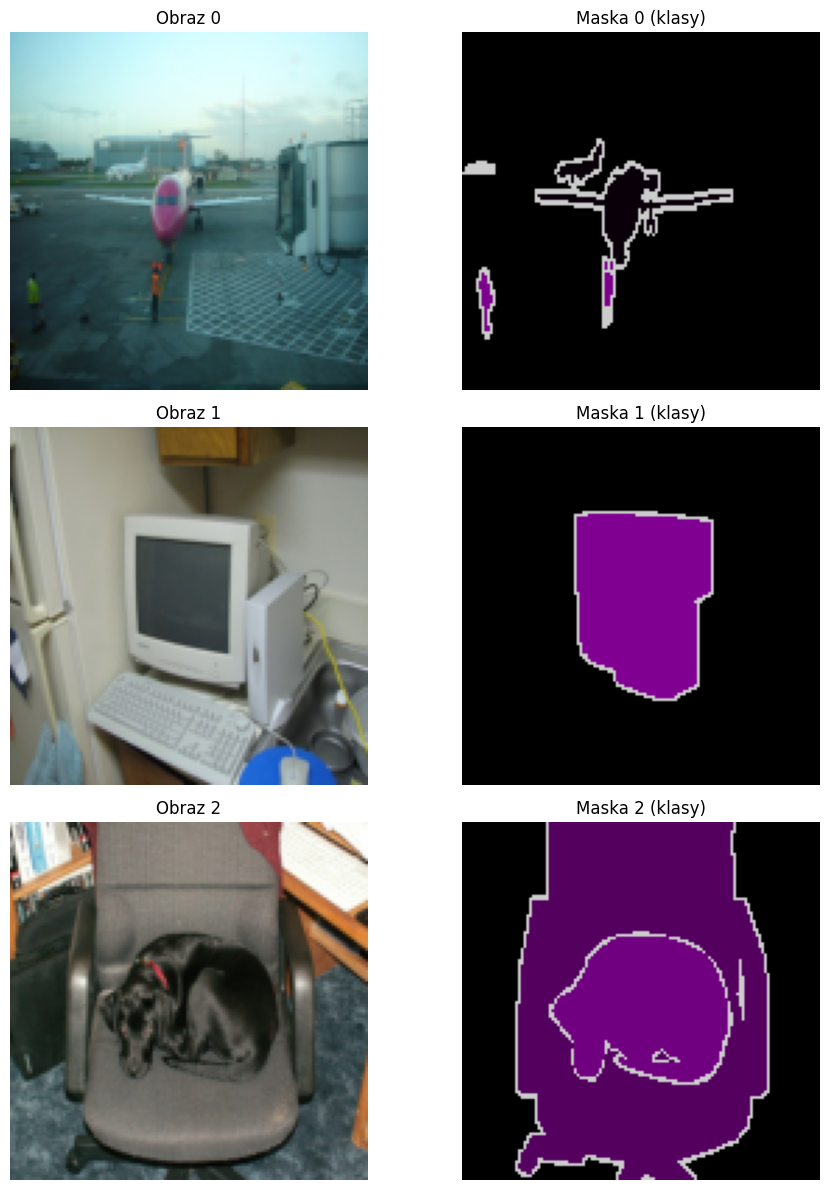

In [5]:
import matplotlib.pyplot as plt

def visualize_input_samples(dataset, num_samples=3):
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    for i in range(num_samples):
        img, mask = dataset[i]
        # Denormalizacja obrazu do wyświetlenia
        img_display = img.permute(1, 2, 0).numpy()
        img_display = img_display * IMAGENET_STD + IMAGENET_MEAN
        img_display = np.clip(img_display, 0, 1)

        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title(f"Obraz {i}")
        axes[i, 0].axis('off')

        # Maska (mapujemy 255 na 0 dla lepszej widoczności lub zostawiamy jako raw)
        axes[i, 1].imshow(mask.numpy(), cmap='nipy_spectral')
        axes[i, 1].set_title(f"Maska {i} (klasy)")
        axes[i, 1].axis('off')
    plt.tight_layout()
    plt.show()

visualize_input_samples(train_ds)

# ConvBlock
Implementowana przeze mnie klasa `ConvBlock` to nasze narzędzie do transformacji danych typu obraz na 2-wymiarową tablicę wektorów o długości równej głębokości kanału dla każdego fragmentu obrazu.
Z tytułu, iż tworzę padding=1 dla filtru (kernela) 3x3 to każdy wektor odpowiada pikselowi na pierwotnym obrazie.
Etapy:
* `Conv2d` - transformujemy obraz mający `input_channel_depth` wartości opisujących dany piksel do obrazu mającego `output_channel_depth` wartości opisujących dany piksel. Z tytułu iż wraz z rozmiarem naszego filtra (3x3) użyliśmy poprawnego paddingu, wektorów końcowych jest tyle samo ile początkowych
* `BatchNorm2d` - bierze kilka zdjęć i równocześnie dla każdego obrazu iteruje po każdym wektorze po kolei i standaryzuje jego wartości.
* `ReLU` - dla każdej wartości wszystkich kanałów wektorów danch wykonuje prosty algorytm: `if x > 0 return x else 0`. Dzięki temu w miejscu `0` umożliwiamy powstanie na przykład łuków i zagięć.


In [6]:
import torch.nn as nn
import torch

kernel_size_for_3x3_kernel=3
padding_combating_3x3kernel_image_resolution=1

class ConvBlock(nn.Module):
    """
    input_channel_depth - głębokość kanału wejściowego danych (obrazu!)
    output_channel_depth - głębokość kanału wyjściowego danych
    """
    def __init__(self, input_channel_depth, output_channel_depth):
        super().__init__() # inicjalizacja obiektu rodzica (nn.Module)
        self.net = nn.Sequential(nn.Conv2d(
                in_channels=input_channel_depth,
                out_channels=output_channel_depth,
                kernel_size=kernel_size_for_3x3_kernel,
                padding=padding_combating_3x3kernel_image_resolution,
            ),
            nn.BatchNorm2d(
                num_features=output_channel_depth
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                in_channels=output_channel_depth,
                out_channels=output_channel_depth,
                kernel_size=3,
                padding=1,
                stride=1),
            nn.BatchNorm2d(
                num_features=output_channel_depth
            ),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

# Konstrukcja Sieci
Definujemy archtekturę wykonawczą modelu.
W `__init__` definujemy *klocki* użyte w `forward`.
## `encX`
Część warstwy Enkodera dokonująca ekstrakcji cech + przygotowania danych do nauki modelu.
Kondensacja: **Konwolucja** + **Normalizacja** + **Funkcja aktywacji**.
Zadania zdefiniowałem w `ConvBlock`, więc użyję go tutaj.
Konwolucją często będę zwiększał głebokość kanałową razy 2.
## `poolX`
Część warstwy Enkodera dokonująca redukcji rozdzielczości danych. Redukuję dane o połowę.
### Zwichnięty Kciuk
Dla wartości domyślnych, pierwsza warstwa enkodera zwięsza głębokość kanałową obrazu o 5-krotnie, redukując rozdzielczość o połowę, co potencjalnie łamie **Rule of Thumb**.
## `bottleneck`
Tutaj dane są najbardziej skompresowane, ale mają najwięcej informacji abstrakcyjnej. Robi `ConvBlock`.
## `upX`
Robimy upsampling by zwięszyć rozdzielczość do pierwotnej. Użyje tutaj `ConvTranspose2d`, chociaż czytałem też o kombinacji `Upsample` + `Convd2`.
## `decX`
Redukuję ilość kanałów.
## `final`
Ostatnia konwolucja, mająca na celu redukcję wektora cech każdego piksela do długości `num_classes`.


In [7]:
class SmallUNet(nn.Module):
    """
    input_channel_depth - głębokość kanału wejściowego (dla klasycznego obrazu istnieją tylko RGB)
    base_channels - wymagana głębokość kanału wyjściowa pierwszej warstwy enkodera. Odniesienie dla kolejnych warstw
    """
    def __init__(self, input_channel_depth=3, base_channels=16, num_classes=21):
        super().__init__()
        self.enc1 = ConvBlock(input_channel_depth, base_channels)
        self.pool1 = nn.MaxPool2d(2)    # 2x2 kernel redukuje 4 piksele -> 1 piksel
        self.enc2 = ConvBlock(base_channels, base_channels * 2)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck=ConvBlock(base_channels * 2, base_channels * 4)

        self.up2 = nn.ConvTranspose2d(base_channels*4, base_channels*2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(base_channels*4, base_channels*2)
        self.up1 = nn.ConvTranspose2d(base_channels*2, base_channels, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(base_channels*2, base_channels)

        self.final = nn.Conv2d(base_channels, num_classes, kernel_size=1)

    def forward(self, x):
        # --- Encoder ---
        s1 = self.enc1(x)
        p1 = self.pool1(s1)
        s2 = self.enc2(p1)
        p2 = self.pool2(s2)

        # --- Bottleneck ---
        b = self.bottleneck(p2)

        # --- Decoder ze Skip-Connections ---
        u2 = self.up2(b)
        d2 = self.dec2(torch.cat([u2, s2], dim=1))

        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, s1], dim=1))

        return self.final(d1)

model = SmallUNet(base_channels=512).to(device)

In [8]:
criterion = nn.CrossEntropyLoss(ignore_index=CONFIG["ignore_index"])
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])

def pixel_accuracy(logits, targets):
    preds = logits.argmax(dim=1)
    valid = targets != CONFIG["ignore_index"]
    if valid.sum() == 0:
        return 0.0
    return (preds[valid] == targets[valid]).float().mean().item()


best_val_acc = -1.0

for epoch in range(CONFIG["epochs"]):
    model.train()
    running = 0.0
    steps = 0

    for step, (imgs, masks) in enumerate(train_loader):
        if CONFIG["max_steps_per_epoch"] is not None and step >= CONFIG["max_steps_per_epoch"]:
            break
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        logits = model(imgs)
        loss = criterion(logits, masks)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running += loss.item()
        steps += 1

    model.eval()
    accs = []
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            logits = model(imgs)
            accs.append(pixel_accuracy(logits, masks))

    val_acc = float(np.mean(accs))
    train_loss = running / max(1, steps)
    best_val_acc = max(best_val_acc, val_acc)

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | train_loss={train_loss:.4f} | val_pixel_acc={val_acc:.4f}")

print("best_val_acc:", best_val_acc)


Epoch 1/10 | train_loss=1.3732 | val_pixel_acc=0.7299
Epoch 2/10 | train_loss=1.2781 | val_pixel_acc=0.7280
Epoch 3/10 | train_loss=1.2545 | val_pixel_acc=0.7302
Epoch 4/10 | train_loss=1.2247 | val_pixel_acc=0.7297
Epoch 5/10 | train_loss=1.2042 | val_pixel_acc=0.7290
Epoch 6/10 | train_loss=1.1942 | val_pixel_acc=0.7300
Epoch 7/10 | train_loss=1.1800 | val_pixel_acc=0.7299
Epoch 8/10 | train_loss=1.1798 | val_pixel_acc=0.7299
Epoch 9/10 | train_loss=1.1593 | val_pixel_acc=0.7074
Epoch 10/10 | train_loss=1.1477 | val_pixel_acc=0.7336
best_val_acc: 0.7336102375289896


### Wizualizacja wyników treningu

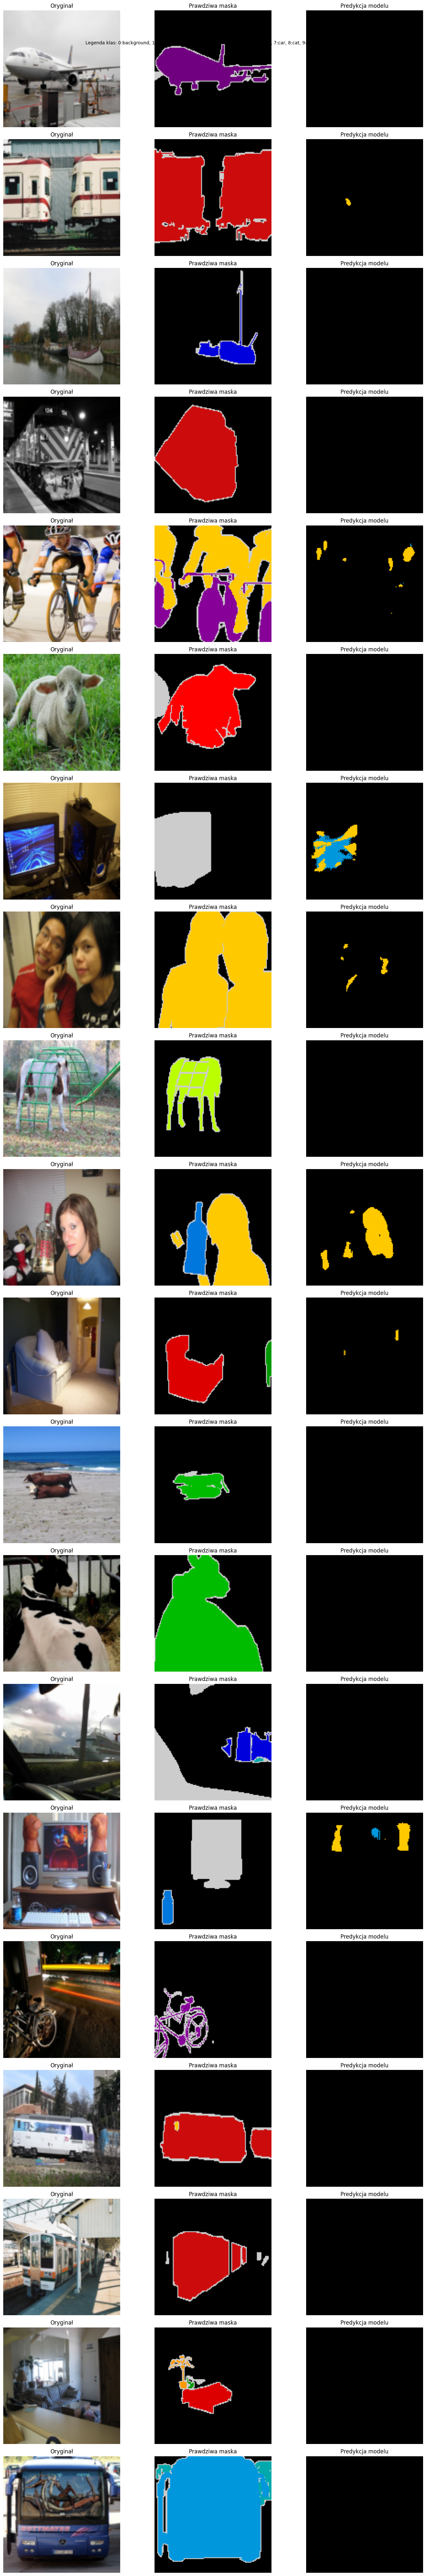

In [24]:


VOC_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]
def visualize_predictions(model, dataset, device, num_samples=20):
    model.eval()
    num_samples = min(num_samples, len(dataset))
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 4 * num_samples), squeeze=False)

    with torch.no_grad():
        for i in range(num_samples):
            img, mask = dataset[i]
            input_batch = img.unsqueeze(0).to(device)
            logits = model(input_batch)
            preds = logits.argmax(dim=1).cpu().squeeze(0)

            # Obraz oryginalny
            img_display = img.permute(1, 2, 0).numpy() * IMAGENET_STD + IMAGENET_MEAN
            img_display = np.clip(img_display, 0, 1)

            axes[i, 0].imshow(img_display)
            axes[i, 0].set_title("Oryginał")

            # Prawdziwa maska
            axes[i, 1].imshow(mask, cmap='nipy_spectral', vmin=0, vmax=20)
            axes[i, 1].set_title("Prawdziwa maska")

            # Predykcja
            axes[i, 2].imshow(preds, cmap='nipy_spectral', vmin=0, vmax=20)
            axes[i, 2].set_title("Predykcja modelu")

            for ax in axes[i]: ax.axis('off')

    plt.suptitle("Legenda klas: " + ", ".join([f"{i}:{c}" for i, c in enumerate(VOC_CLASSES[:11])]) + "...", fontsize=10)
    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_ds, device)



# Wyniki
`train_loss` maleje.
`val_pixel_acc` ma sufit przy ~0.73 i nie polepsza się
## Base=4
```
Epoch 1/10 | train_loss=2.6616 | val_pixel_acc=0.5046
Epoch 2/10 | train_loss=1.8112 | val_pixel_acc=0.7306
Epoch 3/10 | train_loss=1.3941 | val_pixel_acc=0.7306
Epoch 4/10 | train_loss=1.2905 | val_pixel_acc=0.7306
Epoch 5/10 | train_loss=1.2545 | val_pixel_acc=0.7306
Epoch 6/10 | train_loss=1.2415 | val_pixel_acc=0.7306
Epoch 7/10 | train_loss=1.2290 | val_pixel_acc=0.7306
Epoch 8/10 | train_loss=1.2250 | val_pixel_acc=0.7306
Epoch 9/10 | train_loss=1.2129 | val_pixel_acc=0.7306
Epoch 10/10 | train_loss=1.2056 | val_pixel_acc=0.7306
best_val_acc: 0.7305806906341197
```

## Base=8
```
Epoch 1/10 | train_loss=2.6178 | val_pixel_acc=0.6974
Epoch 2/10 | train_loss=1.6538 | val_pixel_acc=0.7237
Epoch 3/10 | train_loss=1.2946 | val_pixel_acc=0.7304
Epoch 4/10 | train_loss=1.2300 | val_pixel_acc=0.7305
Epoch 5/10 | train_loss=1.2171 | val_pixel_acc=0.7304
Epoch 6/10 | train_loss=1.1998 | val_pixel_acc=0.7301
Epoch 7/10 | train_loss=1.1966 | val_pixel_acc=0.7305
Epoch 8/10 | train_loss=1.1913 | val_pixel_acc=0.7298
Epoch 9/10 | train_loss=1.1757 | val_pixel_acc=0.7304
Epoch 10/10 | train_loss=1.1713 | val_pixel_acc=0.7311
best_val_acc: 0.7311235756336988
```

## Base=16
```
Epoch 1/10 | train_loss=2.1328 | val_pixel_acc=0.7236
Epoch 2/10 | train_loss=1.3136 | val_pixel_acc=0.7300
Epoch 3/10 | train_loss=1.2289 | val_pixel_acc=0.7304
Epoch 4/10 | train_loss=1.2162 | val_pixel_acc=0.7303
Epoch 5/10 | train_loss=1.2001 | val_pixel_acc=0.7306
Epoch 6/10 | train_loss=1.1885 | val_pixel_acc=0.7309
Epoch 7/10 | train_loss=1.1802 | val_pixel_acc=0.7335
Epoch 8/10 | train_loss=1.1639 | val_pixel_acc=0.7317
Epoch 9/10 | train_loss=1.1489 | val_pixel_acc=0.7331
Epoch 10/10 | train_loss=1.1396 | val_pixel_acc=0.7325
best_val_acc: 0.7335370590726098
```

## Base=32
```
Epoch 1/10 | train_loss=1.6612 | val_pixel_acc=0.7272
Epoch 2/10 | train_loss=1.2373 | val_pixel_acc=0.7295
Epoch 3/10 | train_loss=1.2142 | val_pixel_acc=0.7296
Epoch 4/10 | train_loss=1.2011 | val_pixel_acc=0.7312
Epoch 5/10 | train_loss=1.1742 | val_pixel_acc=0.7312
Epoch 6/10 | train_loss=1.1505 | val_pixel_acc=0.7334
Epoch 7/10 | train_loss=1.1381 | val_pixel_acc=0.7318
Epoch 8/10 | train_loss=1.1182 | val_pixel_acc=0.7337
Epoch 9/10 | train_loss=1.1072 | val_pixel_acc=0.7323
Epoch 10/10 | train_loss=1.0944 | val_pixel_acc=0.7344
best_val_acc: 0.7344089964261422
```

## Base=64
```
Epoch 1/10 | train_loss=1.5455 | val_pixel_acc=0.7285
Epoch 2/10 | train_loss=1.2512 | val_pixel_acc=0.7256
Epoch 3/10 | train_loss=1.2233 | val_pixel_acc=0.7316
Epoch 4/10 | train_loss=1.1996 | val_pixel_acc=0.7268
Epoch 5/10 | train_loss=1.1709 | val_pixel_acc=0.7333
Epoch 6/10 | train_loss=1.1533 | val_pixel_acc=0.7289
Epoch 7/10 | train_loss=1.1303 | val_pixel_acc=0.7315
Epoch 8/10 | train_loss=1.1211 | val_pixel_acc=0.7294
Epoch 9/10 | train_loss=1.1027 | val_pixel_acc=0.7267
Epoch 10/10 | train_loss=1.0947 | val_pixel_acc=0.7278
best_val_acc: 0.7332947848589866
```

## Base=128
```
Epoch 1/10 | train_loss=1.3973 | val_pixel_acc=0.7302
Epoch 2/10 | train_loss=1.2290 | val_pixel_acc=0.7295
Epoch 3/10 | train_loss=1.1982 | val_pixel_acc=0.7300
Epoch 4/10 | train_loss=1.1879 | val_pixel_acc=0.7293
Epoch 5/10 | train_loss=1.1729 | val_pixel_acc=0.7307
Epoch 6/10 | train_loss=1.1471 | val_pixel_acc=0.7313
Epoch 7/10 | train_loss=1.1396 | val_pixel_acc=0.7330
Epoch 8/10 | train_loss=1.1291 | val_pixel_acc=0.7296
Epoch 9/10 | train_loss=1.1050 | val_pixel_acc=0.7325
Epoch 10/10 | train_loss=1.1008 | val_pixel_acc=0.7345
best_val_acc: 0.7344946368382528
```

## Base=256
```
Epoch 1/10 | train_loss=1.3795 | val_pixel_acc=0.7306
Epoch 2/10 | train_loss=1.2445 | val_pixel_acc=0.7236
Epoch 3/10 | train_loss=1.2211 | val_pixel_acc=0.7287
Epoch 4/10 | train_loss=1.2083 | val_pixel_acc=0.7284
Epoch 5/10 | train_loss=1.1887 | val_pixel_acc=0.7306
Epoch 6/10 | train_loss=1.1784 | val_pixel_acc=0.7300
Epoch 7/10 | train_loss=1.1496 | val_pixel_acc=0.7287
Epoch 8/10 | train_loss=1.1327 | val_pixel_acc=0.7200
Epoch 9/10 | train_loss=1.1249 | val_pixel_acc=0.7305
Epoch 10/10 | train_loss=1.1153 | val_pixel_acc=0.7340
best_val_acc: 0.7340432285935015
```